In [1]:
import pandas as pd
import numpy as np
import nltk

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Dataset Path:", path)

data = pd.read_csv(os.path.join(path, 'IMDB Dataset.csv'))
data.head()

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset Path: /kaggle/input/imdb-dataset-of-50k-movie-reviews


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

import re

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)

    tokens = text.split()

    new_tokens = []
    i = 0
    while i < len(tokens):
        if tokens[i] == "not" and i+1 < len(tokens):
            new_tokens.append("not_" + tokens[i+1])  # 🔥 key
            i += 2
        else:
            new_tokens.append(tokens[i])
            i += 1

    tokens = new_tokens
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)

data['clean_text'] = data['review'].apply(preprocess)

data[['review', 'clean_text']].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,review,clean_text
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [5]:
vectorizer =TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),   # unigram + bigram
    min_df=2,
    max_df=0.9
)

X = vectorizer.fit_transform(data['clean_text'])
y = data['sentiment']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(C=2, max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM":  LinearSVC(C=1.5)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {acc}")

Naive Bayes Accuracy: 0.868
Logistic Regression Accuracy: 0.8964
Random Forest Accuracy: 0.8581
SVM Accuracy: 0.8862


In [8]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

results_df

,Model,Accuracy
1,Logistic Regression,0.8964
3,SVM,0.8862
0,Naive Bayes,0.8680
2,Random Forest,0.8581


In [9]:
best_model_name = results_df.iloc[0]['Model']
print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: Logistic Regression


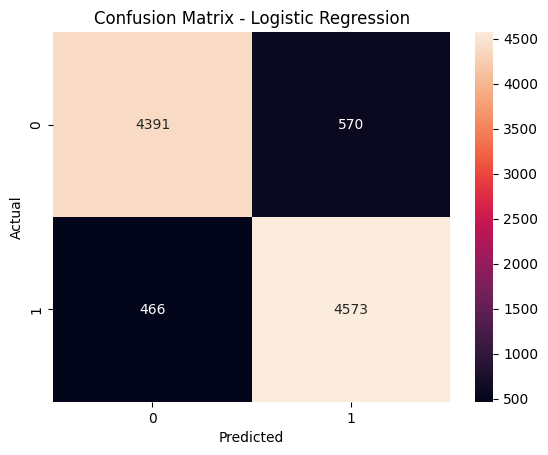

In [10]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      4961
    positive       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [12]:
import pickle

pickle.dump(best_model, open('model.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))

In [13]:
from google.colab import files
files.download('model.pkl')
files.download('vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>